In [54]:
%run "/home/nichettg/Codici/Laboratorio/moduli.py"

In [55]:
def nome (stringa):
    """
    Estrae il nome, cioè la frequenza, dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace('./Data/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [56]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

In [57]:
gf.display_dizionario(dati)

# 2. Analisi

## 2.1 Confronto Frequenze Forzanti

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


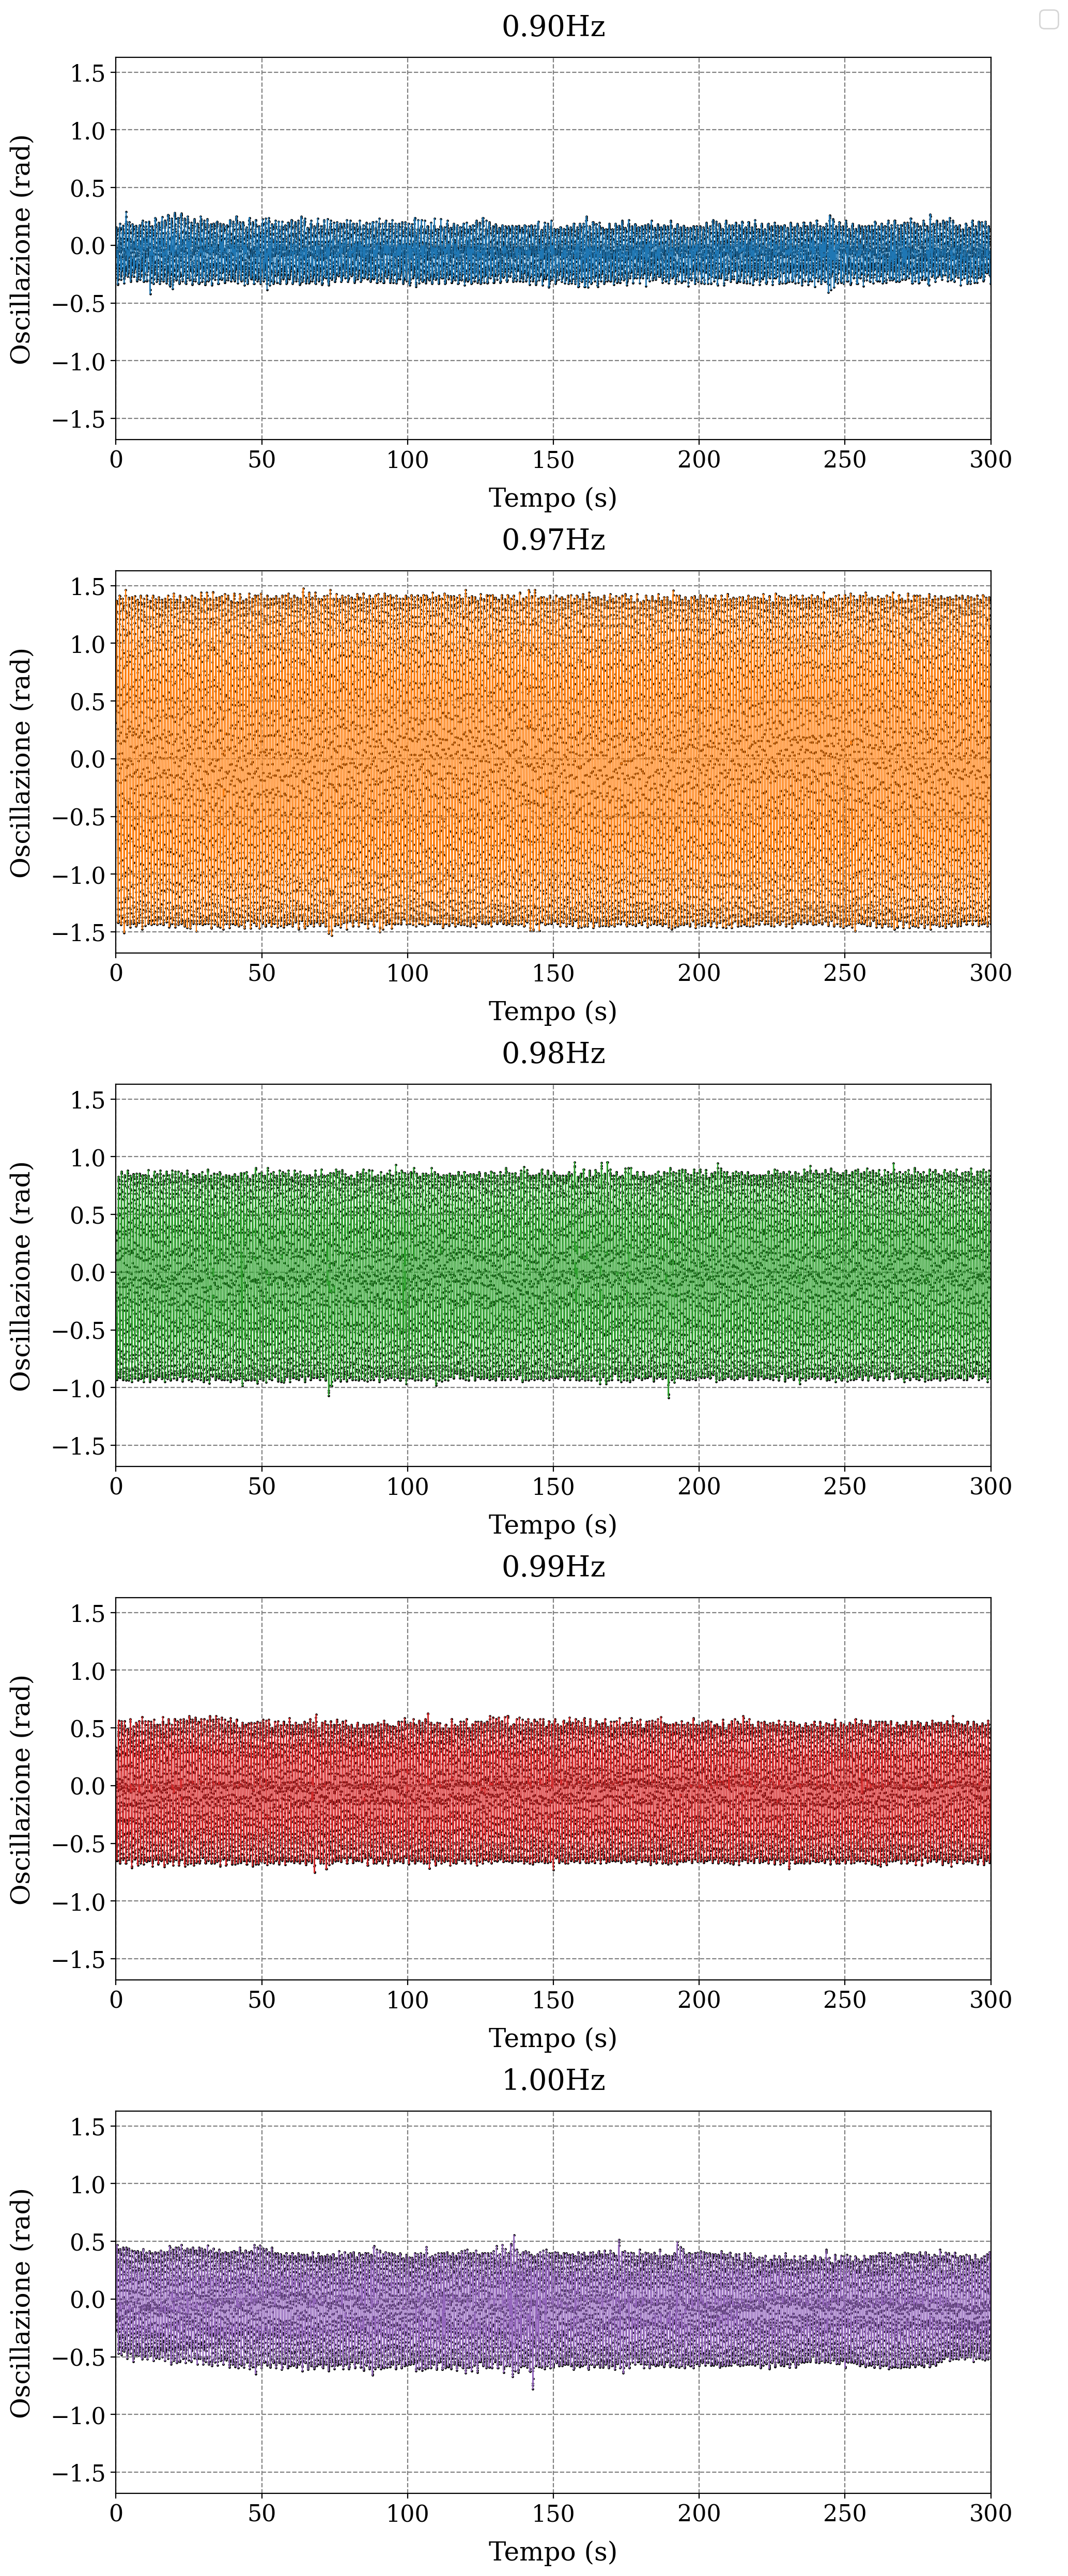

In [58]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] * (2*np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, "./Images/ConfrontoForzanti.pdf")

## 2.2 Calcolo Ampiezze Medie

Raggio dell'intorno rispetto al quale i valori salvati sono i massimi. Di tali valori verrà poi calcolata la media, considerata come ampiezza media.

In [59]:
grafico_controllo = True

Vengono trovati massimi e minimi delle oscillazioni, viene poi fatta la media dei minimi e dei massimi singolarmente per poi fare la media tra i due. Vengono supposti gaussiani il campione dei massimi e quello dei minimi, considerando poi come ampiezza di oscillazione la media tra i due.

Serie 0.90Hz: 209 massimi e 233 minimi trovati 
 Periodo = 1.11 s 
 Intorno = 54
Serie 0.97Hz: 259 massimi e 247 minimi trovati 
 Periodo = 1.03 s 
 Intorno = 50
Serie 0.98Hz: 243 massimi e 244 minimi trovati 
 Periodo = 1.02 s 
 Intorno = 50
Serie 0.99Hz: 242 massimi e 225 minimi trovati 
 Periodo = 1.01 s 
 Intorno = 50
Serie 1.00Hz: 252 massimi e 242 minimi trovati 
 Periodo = 1.00 s 
 Intorno = 50


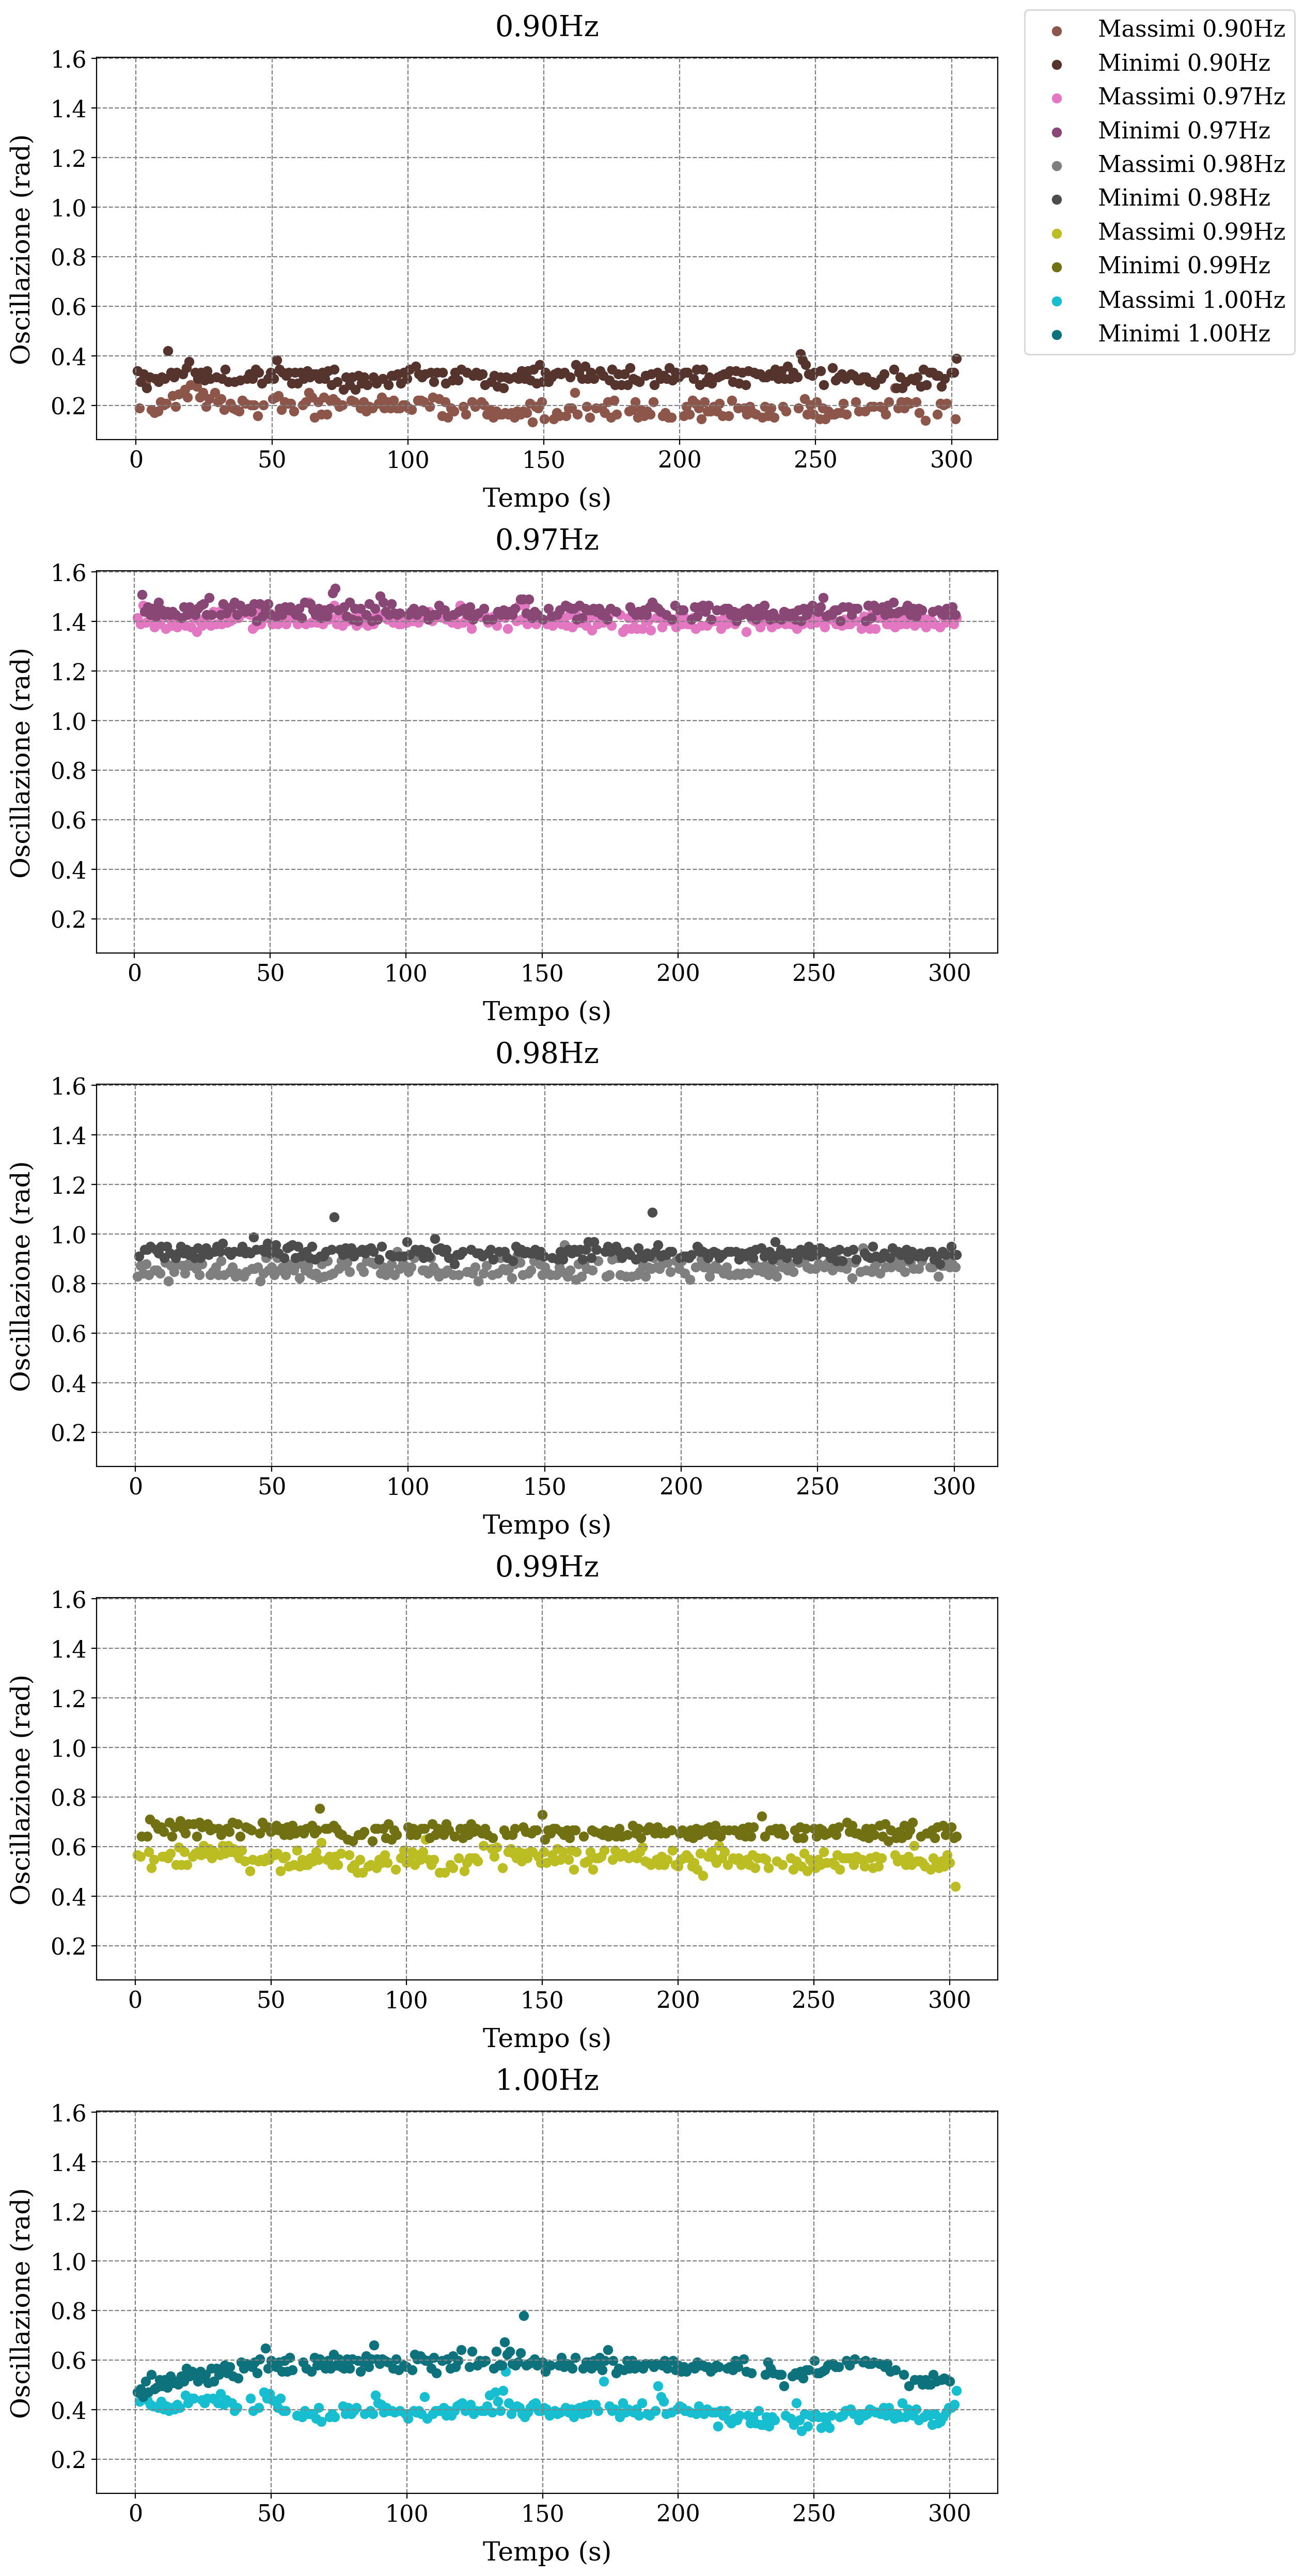

In [66]:
ampiezze = {}

if grafico_controllo: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati.keys()):
    valori = dati[serie]["pendolo"] * (2*np.pi)
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = int((periodo / 2) * 50)

    fine_forzante = np.argmin(abs(dati[titolo]["forzante"]))

    for j, val in enumerate(valori):
        if j > fine_forzante:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(abs(val))
            minimi_t.append(tempi[j])

    ampiezze[serie] = (np.mean(massimi) + np.mean(minimi)) / 2

    print(f"Serie {serie}: {len(massimi)} massimi e {len(minimi)} minimi trovati \n Periodo = {periodo:.2f} s \n Intorno = {2 * raggio}")
    
    if grafico_controllo:
        ax = axes[i]
        colore = next(color_cycle)
        ax.scatter(massimi_t, massimi, color=colore, label=f"Massimi {serie}")
        ax.scatter(minimi_t, minimi, color=gf.darken(colore), label=f"Minimi {serie}")
        gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Oscillazione (rad)")
if grafico_controllo: gf.salva_grafico(fig, f"./Images/ConfrontoMassimi.pdf")

In [61]:
gf.display_dizionario(ampiezze)


0.90Hz,0.25492303464828503
0.97Hz,1.4219627737610572
0.98Hz,0.894516874784868
0.99Hz,0.6063479015543063
1.00Hz,0.48359870703290186


## 2.3 Fit Lorentziano

---

$$
L(x) = \frac{A}{(B + x^2)^2 + C x^2}
$$

dove:

- ( $A$ ): costante di scala, legata all'altezza del picco  
- ( $B = \omega_0^2$ ): frequenza di risonanza, corrisponde alla posizione del picco  
- ( $C = \gamma^2$ ): larghezza a metà altezza (HWHM), legata allo smorzamento del sistema

$$
L(x) = \frac{A}{(\omega_0^2 + x^2)^2 + \gamma^2 x^2}
$$

---

Seleziona se eseguire o no il fit lorentziano.

In [62]:
fit_lorentziano = True

Fit lorentziano:

A: $(36.9 \pm 5.5) \times 10^{-4}$

B: $(-918.3 \pm 6.2) \times 10^{-3}$

C: $(22.5 \pm 3.8) \times 10^{-4}$

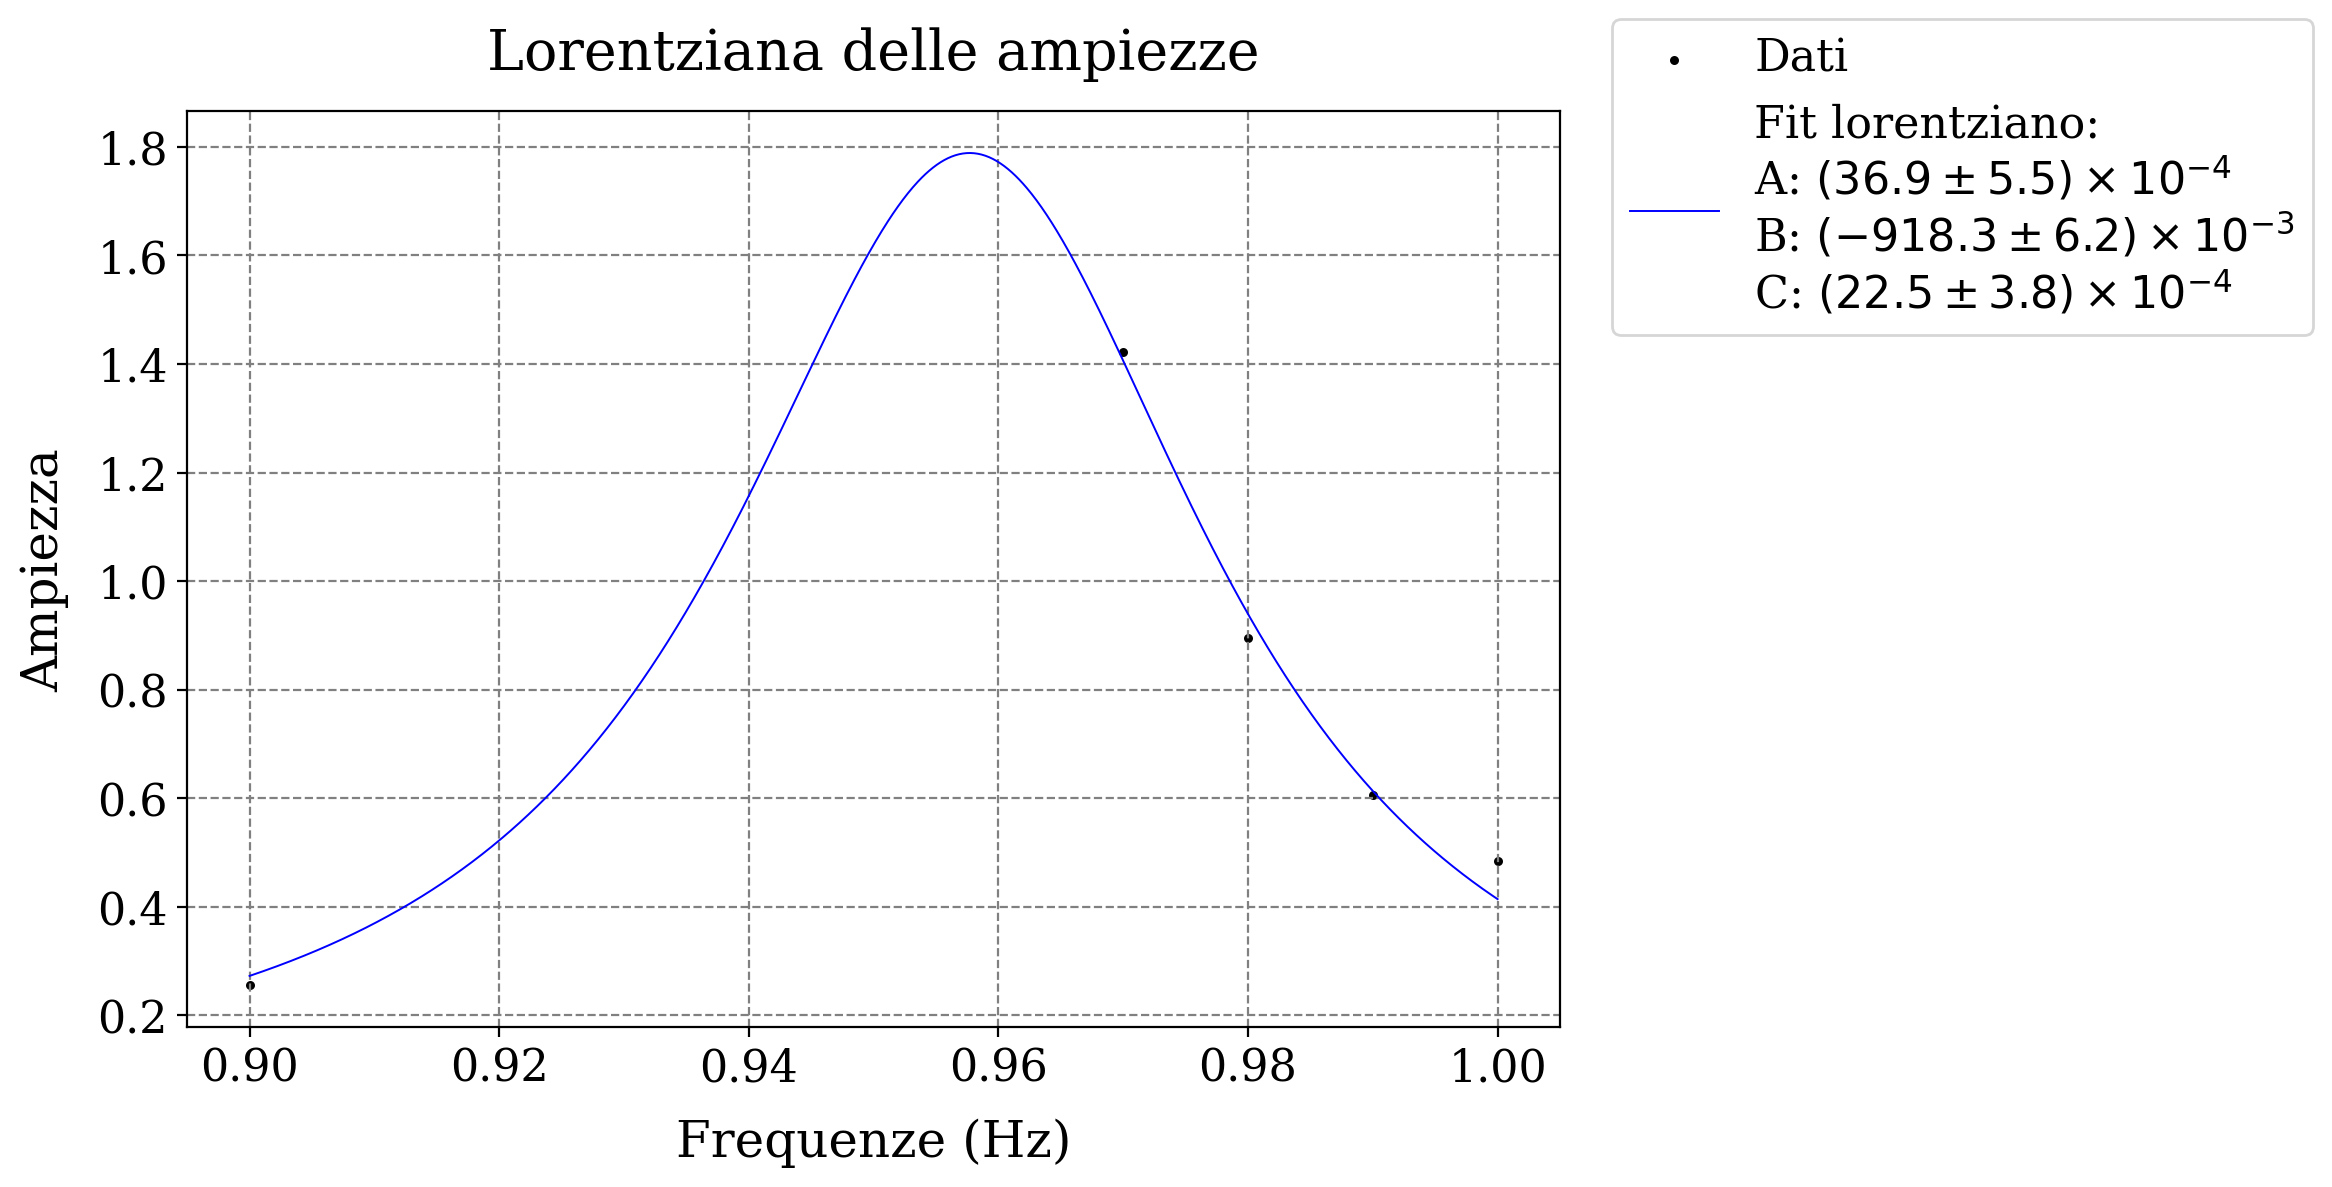

In [63]:
from scipy.optimize import curve_fit
from IPython.display import display, Markdown

def lorentziana(x, A, B, C):
    return A / ((x**2 + B)**2 + C * x**2)

frequenze = [float(key.replace('Hz', '')) for key in dati.keys()]
ampiezze_valori = list(ampiezze.values())

fig, ax = plt.subplots()
ax.scatter(frequenze, ampiezze_valori, color='black', label='Dati', s=5)

if fit_lorentziano:

    A0 = max(ampiezze_valori)
    B0 = np.mean(frequenze)**2
    C0 = 10

    p0 = [A0, B0, C0]
    popt, pcov = curve_fit(
        lorentziana,
        frequenze,
        ampiezze_valori,
        p0=p0
    )
    perr = np.sqrt(np.diag(pcov))

    label = [
        "Fit lorentziano:",
        rf"A: {gf.formatta_errore(popt[0], perr[0])}",
        rf"B: {gf.formatta_errore(popt[1], perr[1])}",
        rf"C: {gf.formatta_errore(popt[2], perr[2])}",
    ]

    x_fit = np.linspace(min(frequenze), max(frequenze), 1000)
    y_fit = lorentziana(x_fit, *popt)
    ax.plot(x_fit, y_fit, color='blue', linewidth=0.7, label='\n'.join(label))

    display(Markdown('\n\n'.join(label)))

gf.parametri_grafico(ax, "Lorentziana delle ampiezze", "Frequenze (Hz)", "Ampiezza")
gf.salva_grafico(fig, "./Images/Lorentziana.pdf")

## 2.4 Confronto Frequenze Smorzate

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


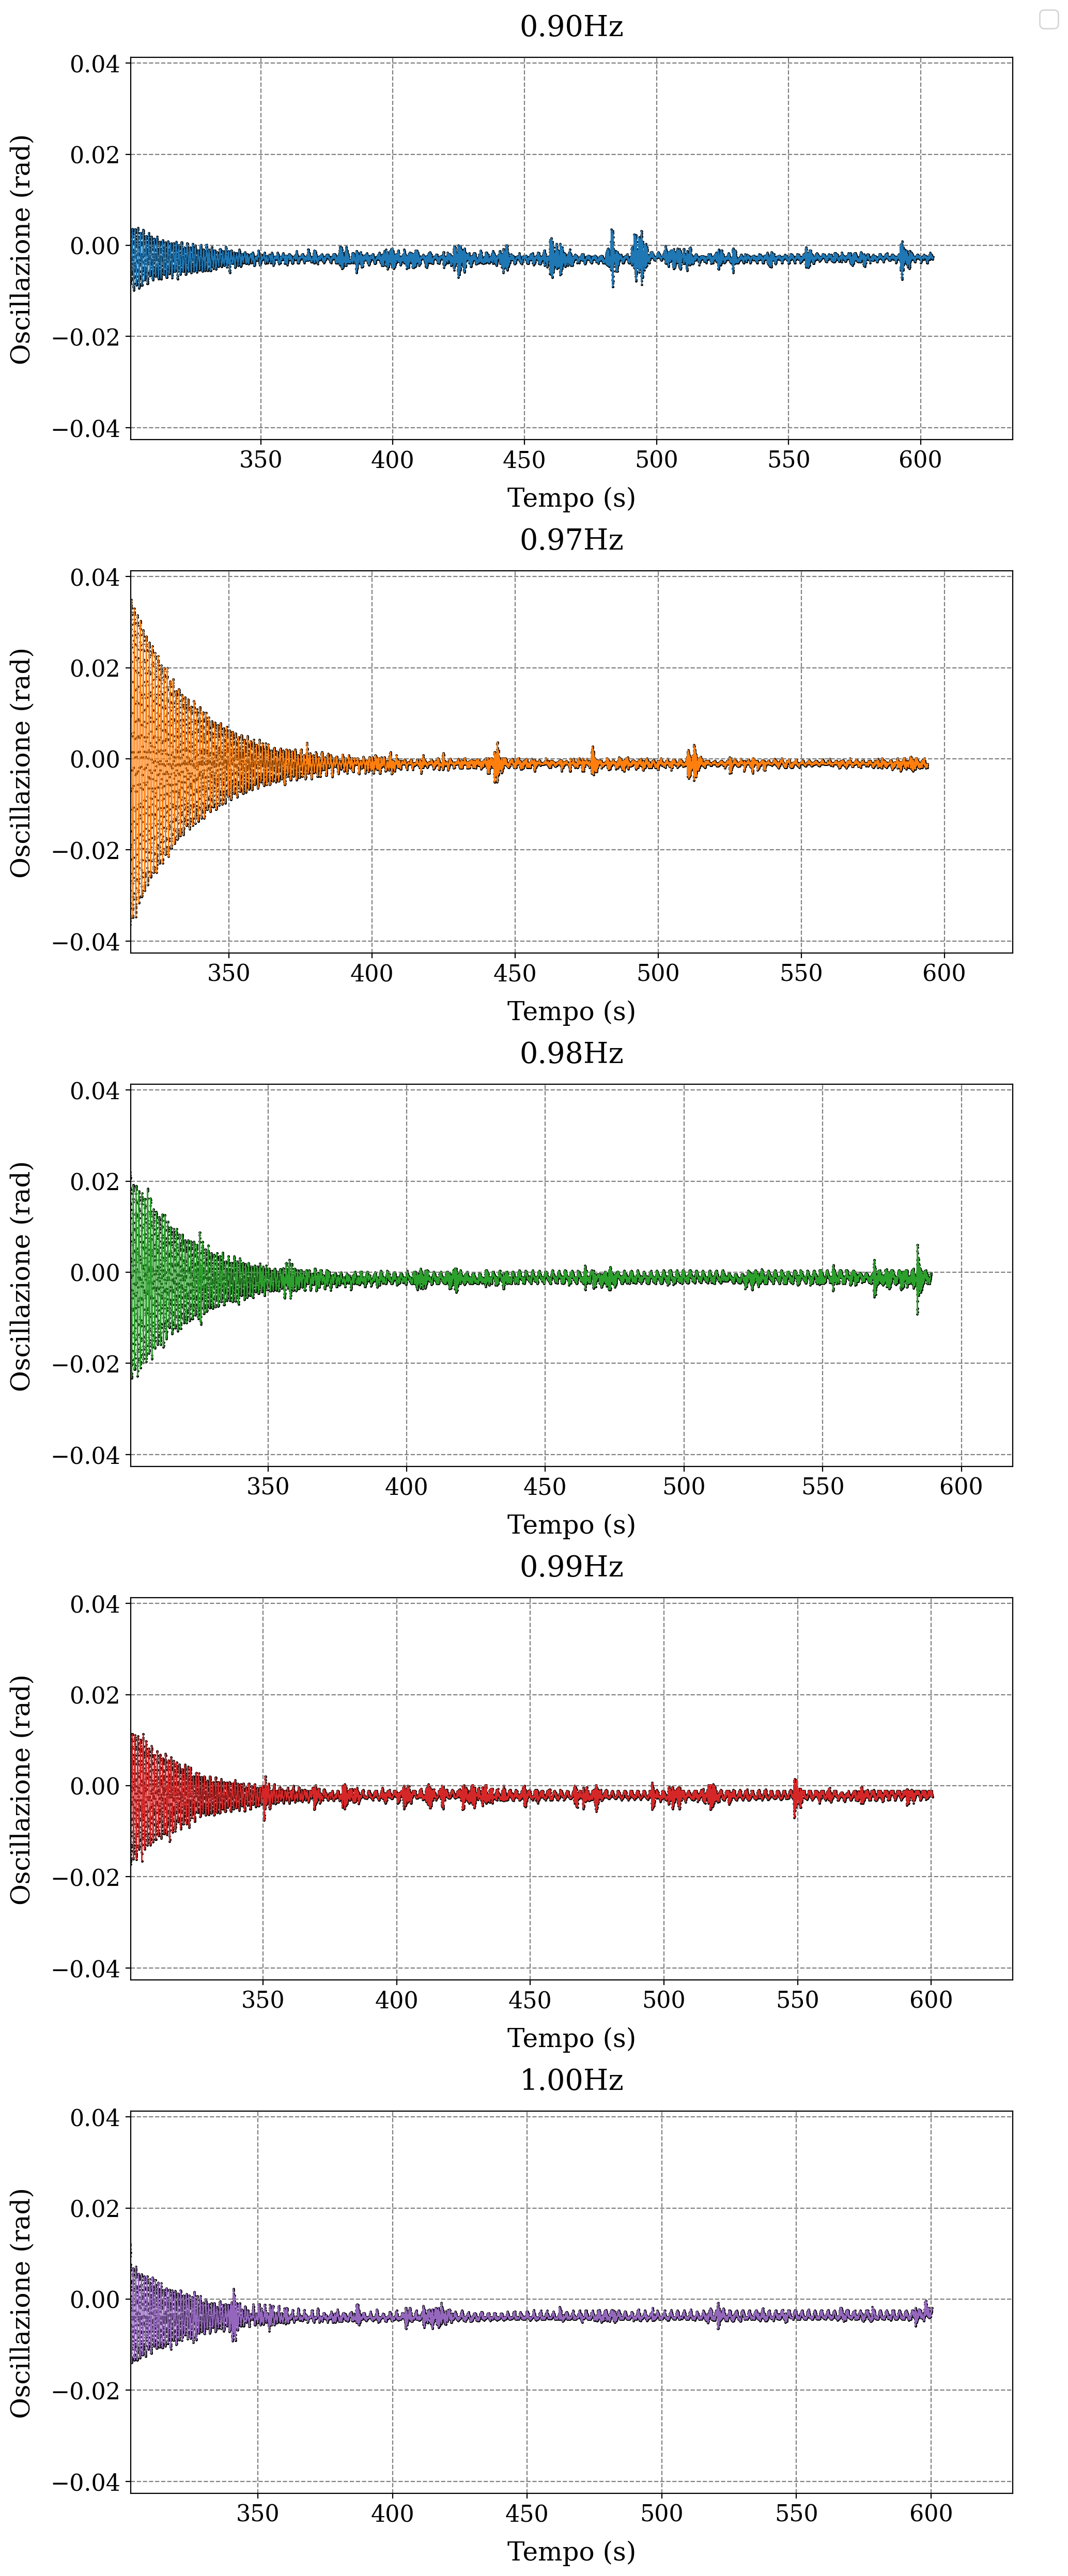

In [64]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] / (2*np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")

    # Calcolo indice di fine oscillazione forzante (inizio smorzamento)
    fine = np.argmin(abs(dati[titolo]["forzante"]))
    ax.set_xlim(x[fine],None)
gf.salva_grafico(fig, "./Images/ConfrontoSmorzati.pdf")

# Test

In [65]:
for chiave, serie in dati.items():
    tempi = serie['tempo']
    target = 300
    n = np.abs(np.array(tempi) - target).argmin()

    print(f"--- Serie {chiave} ---")
    print(f"Forzante: media = {np.mean(serie['forzante'][:n]):.3f}, deviazione = {np.std(serie['forzante'][:n], ddof=1):.3f}")
    print(f"Pendolo:  media = {np.mean(serie['pendolo'][:n]):.3f},  deviazione = {np.std(serie['pendolo'][:n], ddof=1):.3f}")
    print(f"Ampiezza: media = {np.mean(serie['ampiezza'][:n]):.3f}, deviazione = {np.std(serie['ampiezza'][:n], ddof=1):.3f}")
    print(f"Fase:     media = {np.mean(serie['fase'][:n]):.3f},     deviazione = {np.std(serie['fase'][:n], ddof=1):.3f}\n")


--- Serie 0.90Hz ---
Forzante: media = 0.149, deviazione = 23.809
Pendolo:  media = -0.009,  deviazione = 0.024
Ampiezza: media = 0.089, deviazione = 0.006
Fase:     media = 40.059,     deviazione = 173.513

--- Serie 0.97Hz ---
Forzante: media = 0.162, deviazione = 23.775
Pendolo:  media = -0.004,  deviazione = 0.159
Ampiezza: media = 0.460, deviazione = 0.004
Fase:     media = 44.750,     deviazione = 0.640

--- Serie 0.98Hz ---
Forzante: media = 0.133, deviazione = 23.776
Pendolo:  media = -0.006,  deviazione = 0.099
Ampiezza: media = 0.293, deviazione = 0.006
Fase:     media = 27.823,     deviazione = 0.483

--- Serie 0.99Hz ---
Forzante: media = 0.123, deviazione = 23.769
Pendolo:  media = -0.009,  deviazione = 0.067
Ampiezza: media = 0.201, deviazione = 0.004
Fase:     media = 19.695,     deviazione = 0.491

--- Serie 1.00Hz ---
Forzante: media = 0.158, deviazione = 23.771
Pendolo:  media = -0.013,  deviazione = 0.052
Ampiezza: media = 0.162, deviazione = 0.009
Fase:     media = 